# Perceptrón: Segmentación de Colores en Imagen Real

Entrenamos el perceptrón con pixeles de una pintura de playa
para segmentar las regiones de color: cielo, vegetación, arena, agua, bote.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from PIL import Image
import os

In [2]:
class Perceptron:
    """
    Pseudocódigo:
    0. Inicializar pesos y umbral
    1. epocas_maximas = 100
    2. epoca = 0
    3. tasa_aprendizaje = 0.01
    4-9. Entrenar iterativamente
    """
    def __init__(self, n_entradas, tasa_aprendizaje=0.01, epocas_maximas=100):
        self.pesos = np.random.uniform(-0.5, 0.5, n_entradas)
        self.umbral = np.random.uniform(-0.5, 0.5)
        self.tasa_aprendizaje = tasa_aprendizaje
        self.epocas_maximas = epocas_maximas
        self.historial_errores = []

    def funcion_activacion(self, suma):
        return 1 if suma >= 0 else 0

    def predecir(self, entrada):
        suma = np.dot(entrada, self.pesos) + self.umbral
        return self.funcion_activacion(suma)

    def entrenar(self, X, y):
        epoca = 0
        while epoca < self.epocas_maximas:
            errores_epoca = 0
            for i in range(len(X)):
                salida = self.predecir(X[i])
                error = y[i] - salida
                if error != 0:
                    self.pesos += self.tasa_aprendizaje * error * X[i]
                    self.umbral += self.tasa_aprendizaje * error
                    errores_epoca += 1
            self.historial_errores.append(errores_epoca)
            epoca += 1
            if errores_epoca == 0:
                print(f"    Convergió en época {epoca}")
                break
        return self

## 1. Cargar la imagen

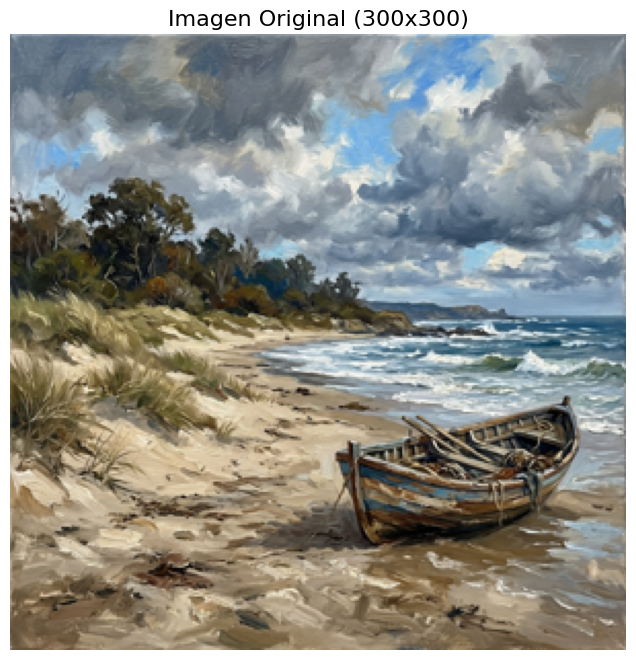

Dimensiones: (300, 300, 3)


In [3]:
ruta_imagen = os.path.join(os.path.dirname(__file__) if '__file__' in dir() else '.', 'imagen_playa.png')
img_original = np.array(Image.open(ruta_imagen).resize((300, 300))) / 255.0
img_original = img_original[:, :, :3]  # solo RGB

plt.figure(figsize=(8, 8))
plt.imshow(img_original)
plt.title('Imagen Original (300x300)', fontsize=16)
plt.axis('off')
plt.show()
print(f"Dimensiones: {img_original.shape}")

## 2. Extraer muestras de entrenamiento por regiones
Seleccionamos manualmente rectángulos representativos de cada zona de color.

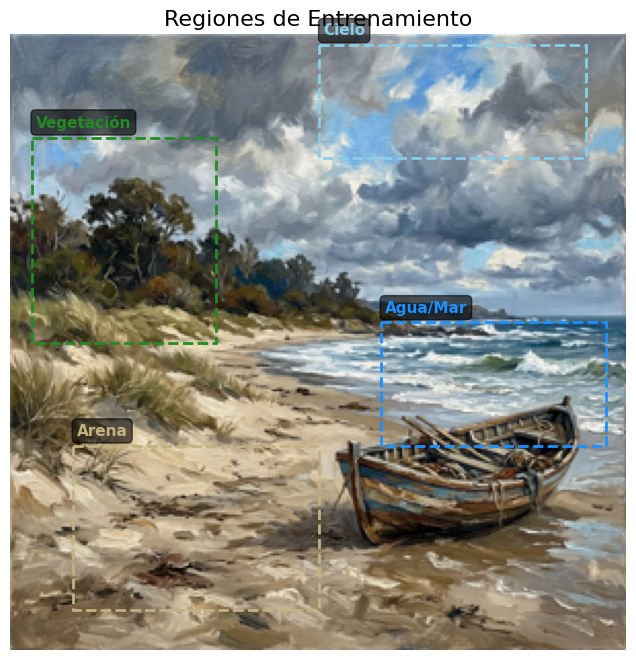


Muestras totales: 32350
  Cielo: 7150 muestras
  Vegetación: 9000 muestras
  Arena: 9600 muestras
  Agua/Mar: 6600 muestras


In [4]:
def extraer_muestras(img, regiones):
    """Extrae pixeles RGB de rectángulos [y1:y2, x1:x2]"""
    muestras = []
    etiquetas = []
    for clase, (y1, y2, x1, x2) in enumerate(regiones):
        pixeles = img[y1:y2, x1:x2].reshape(-1, 3)
        muestras.append(pixeles)
        etiquetas.append(np.full(len(pixeles), clase))
    return np.vstack(muestras), np.concatenate(etiquetas)

# Regiones representativas de la imagen (y1, y2, x1, x2)
# Ajustadas para imagen 300x300
regiones = {
    'Cielo':       (5, 60, 150, 280),     # Zona superior derecha
    'Vegetación':  (50, 150, 10, 100),     # Árboles izquierda
    'Arena':       (200, 280, 30, 150),    # Arena inferior izquierda
    'Agua/Mar':    (140, 200, 180, 290),   # Océano derecha
}

nombres_clases = list(regiones.keys())
colores_vis = ['#87CEEB', '#228B22', '#C2B280', '#1E90FF']
n_clases = len(regiones)

# Visualizar regiones seleccionadas
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img_original)
for i, (nombre, (y1, y2, x1, x2)) in enumerate(regiones.items()):
    rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, 
                          linewidth=2, edgecolor=colores_vis[i], 
                          facecolor='none', linestyle='--')
    ax.add_patch(rect)
    ax.text(x1+2, y1-5, nombre, color=colores_vis[i], fontsize=11,
            fontweight='bold', bbox=dict(boxstyle='round', facecolor='black', alpha=0.6))
ax.set_title('Regiones de Entrenamiento', fontsize=16)
ax.axis('off')
plt.show()

# Extraer datos
X_train, y_train = extraer_muestras(img_original, list(regiones.values()))
print(f"\nMuestras totales: {len(X_train)}")
for i, nombre in enumerate(nombres_clases):
    print(f"  {nombre}: {np.sum(y_train==i)} muestras")

## 3. Entrenar Perceptrones (One-vs-All)

In [5]:
np.random.seed(42)

# Mezclar datos
idx = np.random.permutation(len(X_train))
X_train, y_train = X_train[idx], y_train[idx]

print("=" * 55)
print("ENTRENAMIENTO ONE-VS-ALL")
print("=" * 55)

perceptrones = []
for c in range(n_clases):
    print(f"\nPerceptrón '{nombres_clases[c]}':")
    y_bin = (y_train == c).astype(int)
    p = Perceptron(n_entradas=3, tasa_aprendizaje=0.01, epocas_maximas=200)
    p.entrenar(X_train, y_bin)
    perceptrones.append(p)

# Precisión en entrenamiento
def predecir_clase(x, perceptrones):
    sumas = [np.dot(x, p.pesos) + p.umbral for p in perceptrones]
    return np.argmax(sumas)

pred = np.array([predecir_clase(x, perceptrones) for x in X_train])
precision = np.mean(pred == y_train) * 100
print(f"\nPrecisión en entrenamiento: {precision:.1f}%")

ENTRENAMIENTO ONE-VS-ALL

Perceptrón 'Cielo':

Perceptrón 'Vegetación':

Perceptrón 'Arena':

Perceptrón 'Agua/Mar':

Precisión en entrenamiento: 67.7%


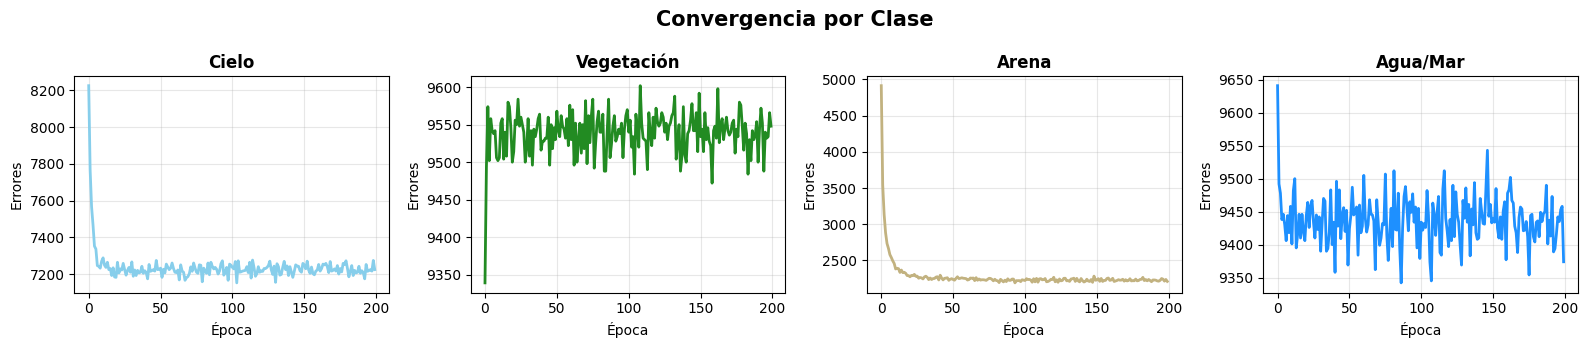

In [6]:
fig, axes = plt.subplots(1, n_clases, figsize=(16, 3.5))
for i in range(n_clases):
    axes[i].plot(perceptrones[i].historial_errores, color=colores_vis[i], linewidth=2)
    axes[i].set_title(f'{nombres_clases[i]}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Época')
    axes[i].set_ylabel('Errores')
    axes[i].grid(True, alpha=0.3)
plt.suptitle('Convergencia por Clase', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Segmentar la imagen completa

Segmentando imagen pixel por pixel...
¡Segmentación completada!


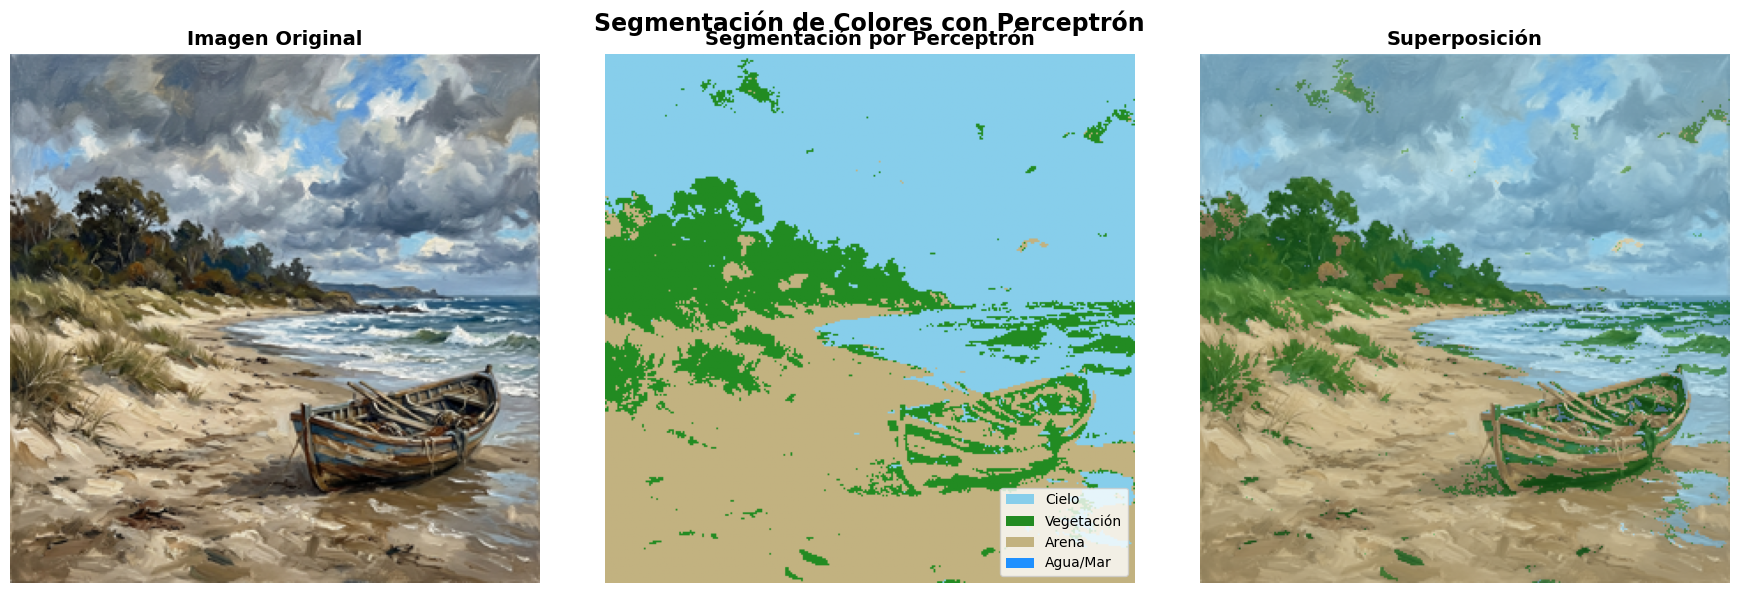

In [7]:
print("Segmentando imagen pixel por pixel...")
alto, ancho, _ = img_original.shape
segmentada = np.zeros((alto, ancho), dtype=int)

# Vectorizado para rapidez
pixeles = img_original.reshape(-1, 3)
for i, pixel in enumerate(pixeles):
    segmentada.flat[i] = predecir_clase(pixel, perceptrones)

print("¡Segmentación completada!")

# Visualizar
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original
axes[0].imshow(img_original)
axes[0].set_title('Imagen Original', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Mapa de segmentación
cmap = ListedColormap(colores_vis)
im = axes[1].imshow(segmentada, cmap=cmap, vmin=0, vmax=n_clases-1)
axes[1].set_title('Segmentación por Perceptrón', fontsize=14, fontweight='bold')
axes[1].axis('off')

# Leyenda
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colores_vis[i], label=nombres_clases[i]) 
                   for i in range(n_clases)]
axes[1].legend(handles=legend_elements, loc='lower right', fontsize=10)

# Superposición coloreada
overlay = np.zeros_like(img_original)
for c in range(n_clases):
    color_rgb = np.array(plt.matplotlib.colors.to_rgb(colores_vis[c]))
    mask = segmentada == c
    overlay[mask] = img_original[mask] * 0.5 + color_rgb * 0.5

axes[2].imshow(overlay)
axes[2].set_title('Superposición', fontsize=14, fontweight='bold')
axes[2].axis('off')

plt.suptitle('Segmentación de Colores con Perceptrón', fontsize=17, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Análisis: distribución de colores por clase

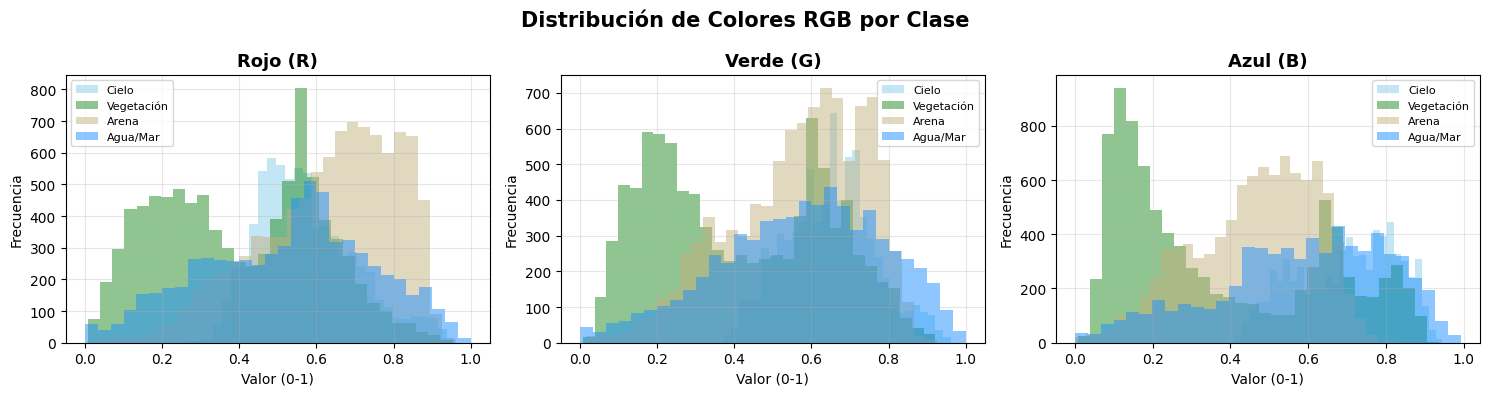

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
canales = ['Rojo (R)', 'Verde (G)', 'Azul (B)']

for ch in range(3):
    for c in range(n_clases):
        mask = y_train == c
        axes[ch].hist(X_train[mask, ch], bins=30, alpha=0.5, 
                      color=colores_vis[c], label=nombres_clases[c])
    axes[ch].set_title(canales[ch], fontsize=13, fontweight='bold')
    axes[ch].set_xlabel('Valor (0-1)')
    axes[ch].set_ylabel('Frecuencia')
    axes[ch].legend(fontsize=8)
    axes[ch].grid(True, alpha=0.3)

plt.suptitle('Distribución de Colores RGB por Clase', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
print("\n" + "=" * 55)
print("RESUMEN FINAL")
print("=" * 55)
print(f"\nClases segmentadas: {n_clases}")
for c in range(n_clases):
    n_pixeles = np.sum(segmentada == c)
    porcentaje = n_pixeles / segmentada.size * 100
    print(f"  {nombres_clases[c]:15s}: {n_pixeles:6d} pixeles ({porcentaje:.1f}%)")
print(f"\nPrecisión entrenamiento: {precision:.1f}%")
print(f"Pesos de cada perceptrón (R, G, B):")
for c in range(n_clases):
    p = perceptrones[c]
    print(f"  {nombres_clases[c]:15s}: [{p.pesos[0]:+.4f}, {p.pesos[1]:+.4f}, {p.pesos[2]:+.4f}] umbral={p.umbral:+.4f}")

print("\n¡Notebook completado!")


RESUMEN FINAL

Clases segmentadas: 4
  Cielo          :  40814 pixeles (45.3%)
  Vegetación     :  15932 pixeles (17.7%)
  Arena          :  33254 pixeles (36.9%)
  Agua/Mar       :      0 pixeles (0.0%)

Precisión entrenamiento: 67.7%
Pesos de cada perceptrón (R, G, B):
  Cielo          : [+0.2042, -0.5283, +0.3454] umbral=-0.0142
  Vegetación     : [-0.1189, +0.1940, -0.1023] umbral=-0.0025
  Arena          : [+0.7984, -1.0428, +0.2651] umbral=-0.0270
  Agua/Mar       : [-0.1196, +0.1481, -0.0610] umbral=-0.0093

¡Notebook completado!
